In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
data_frame = pd.read_csv("diabetes.csv")


In [3]:
data_frame.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### __DiabetesPedigreeFunction__:genetic predisposition to diabetes

In [4]:
data_frame.info() #there is not none value and there is not categorical value

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
data_frame.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Some columns have "min" values of 0 but logically it can't be.

In [6]:
columns_to_check = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in columns_to_check:
    zero_count = (data_frame[col] == 0).sum()
    zero_precentage = (100*zero_count)/len(data_frame)
    print("for ",col," percenntage is:", zero_precentage)

for  Glucose  percenntage is: 0.6510416666666666
for  BloodPressure  percenntage is: 4.557291666666667
for  SkinThickness  percenntage is: 29.557291666666668
for  Insulin  percenntage is: 48.697916666666664
for  BMI  percenntage is: 1.4322916666666667


### Normally, if more than 50% of a column is 0, that column can be deleted. But in this case, since the columns plays a very important role, we should not delete it.<br><br>It makes sense to fill these "0" values with "median" because there seem to be "outlier values" in the data.

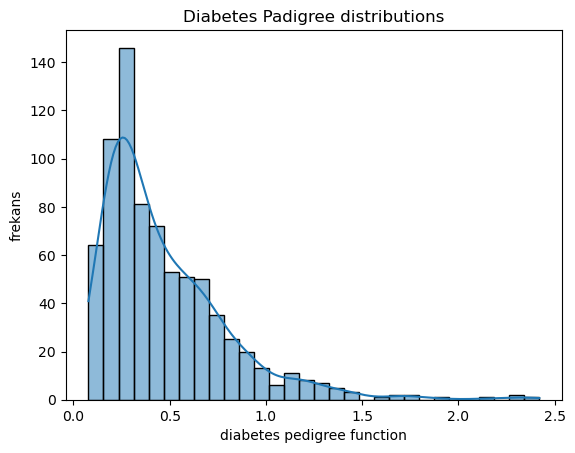

In [7]:
sns.histplot(data_frame["DiabetesPedigreeFunction"], bins=30, kde=True)
plt.title("Diabetes Padigree distributions")
plt.xlabel("diabetes pedigree function")
plt.ylabel("frekans")
plt.show()

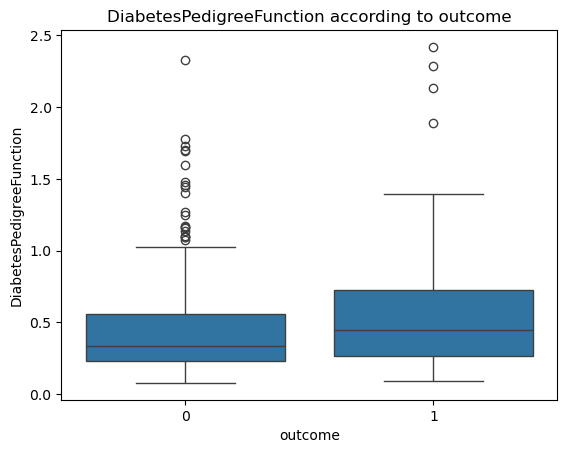

In [8]:
sns.boxplot(x="Outcome", y="DiabetesPedigreeFunction", data=data_frame)
plt.title("DiabetesPedigreeFunction according to outcome")
plt.xlabel("outcome")
plt.ylabel("DiabetesPedigreeFunction")
plt.show()

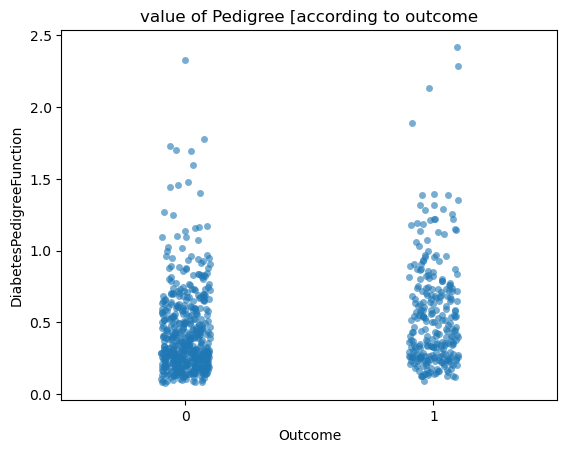

In [9]:
sns.stripplot(x="Outcome", y="DiabetesPedigreeFunction", data=data_frame, jitter=True, alpha=0.6)
plt.title("value of Pedigree [according to outcome")
plt.show()


## Data Inputing

In [10]:
X = data_frame.drop("Outcome", axis=1)
y = data_frame["Outcome"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [11]:
columns_to_fill = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

medians={} #processing the median values for the "test" as well
for col in columns_to_fill:
    median_value = X_train[X_train[col] != 0][col].median()
    medians[col]=median_value
    X_train[col]=X_train[col].replace(0, median_value)

for col in columns_to_fill:
    X_test[col]=X_test[col].replace(0, medians[col])

    

In [12]:
X_train.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,3.907166,121.560261,72.612378,29.040717,142.477199,32.448208,0.469948,33.285016
std,3.385438,29.974412,12.165642,8.312217,80.879330,6.862948,0.328516,11.678337
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.084000,21.000000
25%,1.000000,100.000000,64.000000,25.000000,125.000000,27.600000,0.238250,24.000000
50%,3.000000,117.000000,72.000000,29.000000,129.500000,32.300000,0.370500,29.000000
75%,6.000000,139.750000,80.000000,32.000000,130.000000,36.500000,0.630750,40.000000
max,17.000000,199.000000,122.000000,63.000000,680.000000,67.100000,2.420000,81.000000


In [13]:
X_test.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000
mean,3.597403,122.038961,71.487013,29.376623,144.402597,32.483117,0.479565,33.064935
std,3.304818,32.320876,11.813495,10.513035,104.291511,6.946159,0.343303,12.118519
min,0.000000,61.000000,30.000000,7.000000,23.000000,18.400000,0.078000,21.000000
25%,1.000000,95.250000,64.000000,23.250000,108.250000,26.925000,0.254000,24.000000
50%,3.000000,117.000000,72.000000,29.000000,129.500000,32.300000,0.376500,28.000000
75%,5.750000,142.750000,80.000000,33.750000,129.500000,36.950000,0.603750,41.000000
max,13.000000,197.000000,106.000000,99.000000,846.000000,55.000000,2.329000,69.000000


In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

ada = AdaBoostClassifier()
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)

print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.81      0.82       108
           1       0.58      0.63      0.60        46

    accuracy                           0.75       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.76      0.75      0.76       154

0.7532467532467533
[[87 21]
 [17 29]]


## Hyperparameter Tuning

In [16]:
from sklearn.model_selection import GridSearchCV

[Click to go to the sklearn/AdaBoostClassifier documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html)

In [17]:
ada_params={
    "n_estimators" : [50,80,100,120,140,150,175,200],
    "learning_rate" : [0.001, 0.01, 0.1, 1, 10, 100]
}

In [18]:
grid = GridSearchCV(estimator=AdaBoostClassifier(), param_grid=ada_params, cv=5, verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5, estimator=AdaBoostClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.001, 0.01, 0.1, 1, 10, 100],
                         'n_estimators': [50, 80, 100, 120, 140, 150, 175,
                                          200]},
             verbose=1)

In [19]:
grid.best_params_

{'learning_rate': 1, 'n_estimators': 140}

In [20]:
ada2 = AdaBoostClassifier(learning_rate=1, n_estimators=140)

ada2.fit(X_train, y_train)
y_pred2 = ada2.predict(X_test)

print(classification_report(y_test, y_pred2))
print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.84      0.81      0.82       108
           1       0.59      0.65      0.62        46

    accuracy                           0.76       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.77      0.76      0.76       154

0.7597402597402597
[[87 21]
 [16 30]]


## Another Examples

### Let's try it by deleting the "insulin" and "SkinThickness" columns.

In [21]:
new_data_frame = pd.read_csv("diabetes.csv")

In [22]:
new_data_frame = new_data_frame.drop(["Insulin", "SkinThickness"], axis=1)

In [23]:
new_data_frame.head()

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,33.6,0.627,50,1
1,1,85,66,26.6,0.351,31,0
2,8,183,64,23.3,0.672,32,1
3,1,89,66,28.1,0.167,21,0
4,0,137,40,43.1,2.288,33,1


In [24]:
X_new = new_data_frame.drop("Outcome", axis=1)
y_new = new_data_frame["Outcome"]

from sklearn.model_selection import train_test_split
X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(X_new, y_new, test_size=0.2, random_state=15)


scaler = StandardScaler()

X_new_train = scaler.fit_transform(X_new_train)
X_new_test = scaler.transform(X_new_test)


ada = AdaBoostClassifier()
ada.fit(X_new_train, y_new_train)
y_new_pred = ada.predict(X_new_test)

print(classification_report(y_new_test, y_new_pred))
print(accuracy_score(y_new_test, y_new_pred))
print(confusion_matrix(y_new_test, y_new_pred))

              precision    recall  f1-score   support

           0       0.83      0.81      0.82       108
           1       0.58      0.61      0.60        46

    accuracy                           0.75       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.76      0.75      0.75       154

0.7532467532467533
[[88 20]
 [18 28]]


### As you can see, there wasn't much of a difference here, but let's try "hyperparameter tuning" as well.

In [25]:
grid_new = GridSearchCV(estimator=AdaBoostClassifier(), param_grid=ada_params, cv=5, verbose=1, n_jobs=-1)
grid_new.fit(X_new_train, y_new_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5, estimator=AdaBoostClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.001, 0.01, 0.1, 1, 10, 100],
                         'n_estimators': [50, 80, 100, 120, 140, 150, 175,
                                          200]},
             verbose=1)

In [26]:
grid_new.best_params_

{'learning_rate': 1, 'n_estimators': 140}

In [27]:
ada2_new = AdaBoostClassifier(learning_rate=1, n_estimators=140)

ada2_new.fit(X_new_train, y_new_train)
y_pred2_new = ada2_new.predict(X_new_test)

print(classification_report(y_new_test, y_pred2_new))
print(accuracy_score(y_new_test, y_pred2_new))
print(confusion_matrix(y_new_test, y_pred2_new))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84       108
           1       0.62      0.65      0.64        46

    accuracy                           0.78       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.78      0.78      0.78       154

0.7792207792207793
[[90 18]
 [16 30]]


### as you can see, our score has increased.

## Classification Comparisons

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier



def calculate_metrics(test, predict):
    """
    Calculates and returns classification report, accuracy score and confusion matrix
    """
    cr = classification_report(test, predict)
    acc = accuracy_score(test, predict)
    cm = confusion_matrix(test, predict)

    return cr, acc, cm


models = {
    
    "k-neighbors": KNeighborsClassifier(),
    "decisionTree": DecisionTreeClassifier(),
    "randomForest": RandomForestClassifier(),
    "svc" :  SVC()
}


for model_name, model in models.items():
    # Fit the model to the training data
    model.fit(X_train, y_train)

    # Make predictions on both the training and testing sets
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate and print metrics for the training set
    train_cr, train_acc, train_cm = calculate_metrics(y_train, y_train_pred)
    print(model_name)
    print("Evaluation for training set")
    print("c_report:", train_cr)
    print("acc_score:", train_acc)
    print("matrix:", train_cm)

    print("--------------------")

    # Calculate and print metrics for the testing set
    test_cr, test_acc, test_cm = calculate_metrics(y_test, y_test_pred)
    print("Evaluation for test set")
    print("c_report:", test_cr)
    print("acc_score:", test_acc)
    print("matrix:", test_cm)
    print("\n--------------------\n")

k-neighbors
Evaluation for training set
c_report:               precision    recall  f1-score   support

           0       0.86      0.88      0.87       392
           1       0.78      0.74      0.76       222

    accuracy                           0.83       614
   macro avg       0.82      0.81      0.81       614
weighted avg       0.83      0.83      0.83       614

acc_score: 0.8306188925081434
matrix: [[346  46]
 [ 58 164]]
--------------------
Evaluation for test set
c_report:               precision    recall  f1-score   support

           0       0.80      0.75      0.78       108
           1       0.49      0.57      0.53        46

    accuracy                           0.69       154
   macro avg       0.65      0.66      0.65       154
weighted avg       0.71      0.69      0.70       154

acc_score: 0.6948051948051948
matrix: [[81 27]
 [20 26]]

--------------------

decisionTree
Evaluation for training set
c_report:               precision    recall  f1-score   sup

### The "Decision Tree" and "RandomForest" models gave perfect results ("accuracy": 1.0) on the training set. This means that the model memorized the "train" data. However, when they were transferred to the "test" set, their performance decreased.

## HyperParameter Tuning for DC and RF

In [29]:
dt_model = DecisionTreeClassifier(random_state=0)

dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6]
}

dt_grid_search = GridSearchCV(estimator=dt_model, param_grid=dt_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
dt_grid_search.fit(X_train, y_train)

print("for dc best params: ", dt_grid_search.best_params_)
print("for dc best score: ", dt_grid_search.best_score_)

for dc best params:  {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 6}
for dc best score:  0.7702918832467013


In [30]:
rf_model = RandomForestClassifier(random_state=0)

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 20, 30, None],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid_search = GridSearchCV(estimator=rf_model, param_grid=rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid_search.fit(X_train, y_train)

print("for rf best params: ", rf_grid_search.best_params_)
print("for rf best score: ", rf_grid_search.best_score_)

for rf best params:  {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 300}
for rf best score:  0.7800746368119419


In [31]:
print("for adaboost is 0.759740259")
print("for new adaboost is 0.7792207792")
print("for knn is 0.69480519480")
print("for svc is 0.7272727272")
print("for dc is 0.7702918832")
print("for rf is 0.78007463681")

print("so best score is 0.78007463681. it is rf")

for adaboost is 0.759740259
for new adaboost is 0.7792207792
for knn is 0.69480519480
for svc is 0.7272727272
for dc is 0.7702918832
for rf is 0.78007463681
so best score is 0.78007463681. it is rf
